# Laboratorio de regresión logística

|                |   |
:----------------|---|
| **Nombre**     | David Alejandro Rangel Rodríguez   |
| **Fecha**      | 08/03/2026  |
| **Expediente** | 756203  | 

La regresión logística es una herramienta utilizada para predecir respuestas cualitativas. Al igual que la regresión lineal, es un método sencillo que sirve como un punto de partida para técnicas más avanzadas. Por ejemplo, lo que se conoce como *redes neuronales* o *red de perceptrones multicapa* no es más que una estructura de regresiones logísticas que se alimentan entre sí.

1. Descarga el archivo de créditos y carga los datos (Default.csv). Utiliza `pandas`.

In [5]:
import pandas as pd
df = pd.read_csv("Default.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   default  10000 non-null  object 
 1   student  10000 non-null  object 
 2   balance  10000 non-null  float64
 3   income   10000 non-null  float64
dtypes: float64(2), object(2)
memory usage: 312.6+ KB


2. Utiliza el comando `obj.head()`, donde `obj` es el nombre que le diste a los datos del archivo.

In [6]:
df.head()

,default,student,balance,income
0,No,No,729.526495,44361.625074
1,No,Yes,817.180407,12106.134700
2,No,No,1073.549164,31767.138950
3,No,No,529.250605,35704.493940
4,No,No,785.655883,38463.495880


El comando head arroja los primeras *n* líneas (por defecto 5) de los datos que están en el DataFrame.

3. Utiliza el comando `obj.describe()`.

In [7]:
df.describe()

,balance,income
count,10000.000000,10000.000000
mean,835.374886,33516.981876
std,483.714985,13336.639563
min,0.000000,771.967729
25%,481.731105,21340.462903
50%,823.636973,34552.644802
75%,1166.308386,43807.729275
max,2654.322576,73554.233500


El comando describe toma las columnas que tienen datos numéricos y saca datos estadísticos comunes:
- *n*
- media
- desviación estándar
- valor mínimo
- primer cuartil
- mediana
- tercer cuartil
- valor máximo

3. Vistos estos datos, ¿qué columnas existen en el DataFrame? ¿Qué tipo de datos contienen?

El DataFrame contiene **4 columnas**:

* Variables Categóricas (`object`)

- **`default`** — Si el cliente entró en default 
- **`student`** — Si el cliente es estudiante 

* Variables Numéricas (`float64`)

- **`balance`** — Saldo promedio de tarjeta de crédito → rango: `$0` a `$2,654`
- **`income`** — Ingreso anual del cliente → rango: `$771` a `$73,554`

4. Configura el tipo de dato de las columnas `default` y `student` para cambiarlos a variables categóricas.

`data[columna] = data[columna].astype("category")`

In [8]:
# Convertir columnas categóricas
df['default'] = df['default'].astype('category')
df['student'] = df['student'].astype('category')

# Verificar cambios
df.dtypes

default    category
student    category
balance     float64
income      float64
dtype: object

Imagina que trabajas en un banco y que se te entregan estos datos. Tu objetivo es crear un modelo que ayude a predecir si una persona que solicita un crédito lo va a pagar. Exploremos los datos un poco más antes de crear un modelo.

Veamos primero cómo es la distribución de los valores cuando una persona dejó de pagar y cuando siguió pagando. `Default` es el término utilizado para cuando una persona dejó de pagar.

5. Crea una gráfica de caja para las columnas `income` y `balance`, con los datos agrupados con la columna `default`. Utiliza el comando `obj.boxplot(column=____, by=_____)`

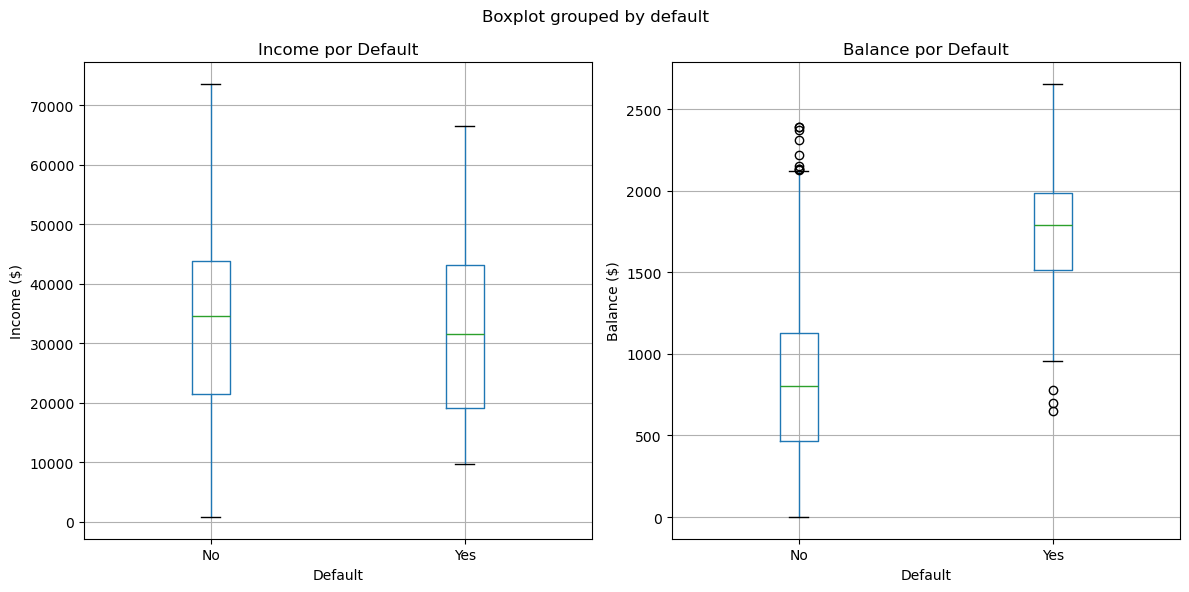

In [9]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
fig.suptitle('Distribución por Default', fontsize=14, fontweight='bold')

# Boxplot de Income por Default
df.boxplot(column='income', by='default', ax=axes[0])
axes[0].set_title('Income por Default')
axes[0].set_xlabel('Default')
axes[0].set_ylabel('Income ($)')

# Boxplot de Balance por Default
df.boxplot(column='balance', by='default', ax=axes[1])
axes[1].set_title('Balance por Default')
axes[1].set_xlabel('Default')
axes[1].set_ylabel('Balance ($)')

plt.tight_layout()
plt.show()

6. Crea una gráfica de dispersión donde el eje *x* sea la columna `balance` y el eje *y* la columna `income`. Utiliza el comando `obj.plot.scatter(x, y, c="default", colormap="PiYG_r", alpha=0.5)`.

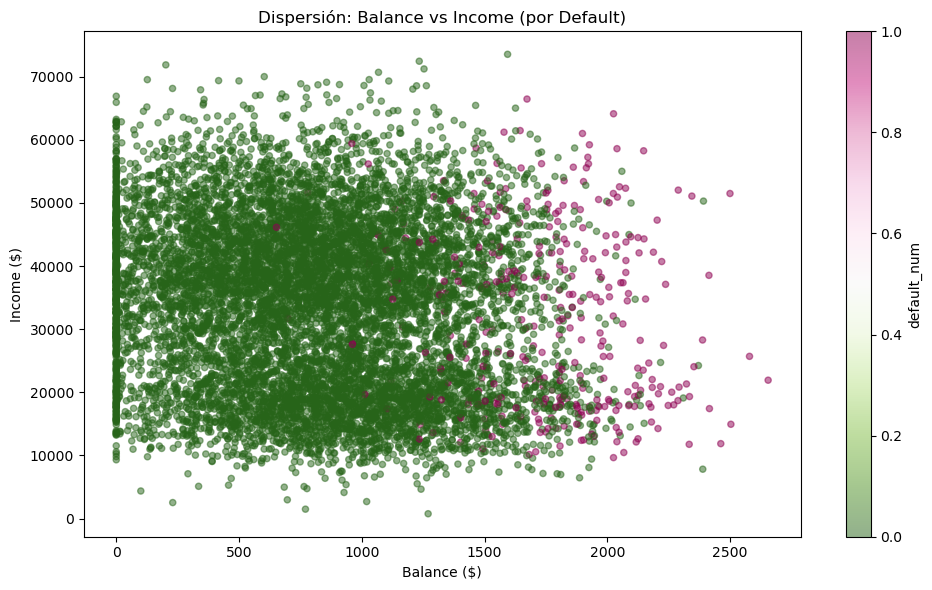

In [10]:
df['default_num'] = df['default'].cat.codes  # No=0, Yes=1

df.plot.scatter(
    x='balance',
    y='income',
    c='default_num',
    colormap='PiYG_r',
    alpha=0.5,
    figsize=(10, 6),
    title='Dispersión: Balance vs Income (por Default)'
)

plt.xlabel('Balance ($)')
plt.ylabel('Income ($)')
plt.tight_layout()
plt.show()

La regresión (lineal o logística) se usa para encontrar una línea que ajuste los datos para tomar una decisión. La línea que buscamos en regresión logística es aquella que nos ayude a separar las diferentes categorías. 

<img style="float: left; " src="https://www.baeldung.com/wp-content/uploads/sites/4/2023/10/decision_boundary_curve.jpg" width="400px" />


## Regresión logística simple

Creemos un modelo simple donde sólo utilizamos una de los factores para predecir una respuesta. Quiero conocer la probabilidad de que una persona deje de pagar su crédito dado el balance que tiene en su cuenta.

$$ P(\text{default}=\text{Yes}|\text{balance}) $$

Por el momento la columna default no contiene valores numéricos, por lo que hay que transformar los datos. Como default es nuestra variable de respuesta (lo que queremos predecir) podemos nombrarla *y*.

Ejecuta el código `y = obj["default"] == "Yes"`. Extrae el factor `balance` en una variable *x*.

In [11]:
y= df["default"] == "Yes"
x = df["balance"]

Crea un gráfico de dispersión donde el eje *x* sea `balance` y el eje *y* sea `default` transformado.

<Axes: xlabel='balance', ylabel='default'>

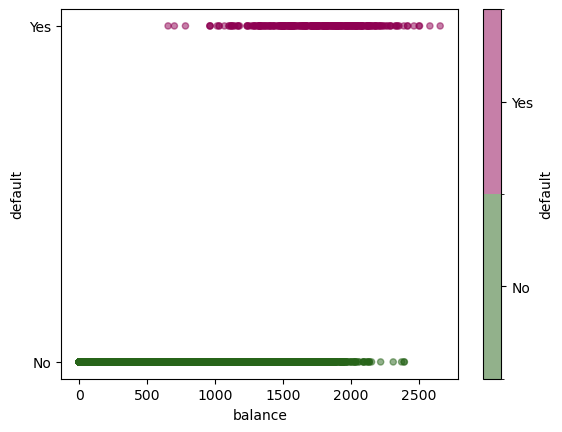

In [12]:
df.plot.scatter(x="balance", y="default", c="default", colormap="PiYG_r", alpha=0.5)

La línea que utilizaremos para predecir la probabilidad es:

$$ p(x) = \frac{1}{1 + e^{-(\beta_0 + \beta_1 x)}} $$

Para nuestro ejemplo de pagos y balance:

$$ P(\text{default}=1|\text{balance}) = \frac{1}{1 + e^{-(\beta_0 + \beta_1  \text{balance})}} $$

Buscamos maximizar la probabilidad de que el modelo tome decisiones correctas. Es decir, que cuando `default` fue verdadero, que la predicción sea 100%, y que cuando `default` fue falso que la predicción sea 0%.

$$ \Pi_{i:y_i=1} p(x_i) \Pi_{i':y_{i'}} (1-p(x_{i'})) $$

La función de costo ya simplificada es la siguiente:

$$ J(\vec{\beta}) = -  \sum_{i=1}^n{[y_i \ln{(\hat{p}(x_i))} + (1-y_i)\ln{(1 - \hat{p}(x_i))}]}$$

Utiliza la clase `LogisticRegression` del módulo `linear_model` de la librería `sklearn` para estimar los parámetros del modelo.

In [26]:
from sklearn.linear_model import LogisticRegression
import numpy as np
log_r= LogisticRegression()

log_r.fit(x.values.reshape(-1, 1), y)
B1= log_r.coef_
B0= log_r.intercept_
print(f'{B0},{B1}')

[-10.65132824],[[0.00549892]]


Muchos aspectos de la regresión logística son similares a la regresión lineal. Podemos medir la precisión de nuestros estimados calculando sus errores estándar. El objetivo de calcular estos errores es asegurar que hay una relación estadísticamente significativa entre el factor y la variable de respuesta.

Los errores estándar se obtienen con el siguiente procedimiento:

1. Calcula las predicciones utilizando los $\beta_0$ y $\beta_1$ encontrados.

In [27]:
x_pred = log_r.predict_proba(x.values.reshape(-1, 1))
p = x_pred[:, 1] # Probability of default=Yes
display(p)

array([1.30568146e-03, 2.11259754e-03, 8.59474814e-03, ...,
       2.46651596e-03, 1.16759635e-01, 7.14476480e-05])

2. Idealmente la probabilidad debería ser 100% o 0%. Si alguna predicción no fue absoluta significa que hay incertidumbre. Calcula $p(1-p)$ para todas tus predicciones.

In [28]:
resultado = p * (1 - p)
display(resultado)

array([1.30397665e-03, 2.10813447e-03, 8.52087844e-03, ...,
       2.46043226e-03, 1.03126823e-01, 7.14425432e-05])

3. Crea una matriz vacía y llena la diagonal con las probabilidades encontradas.

`V = np.diagflat(*p(1-p)*)`

In [29]:
# Crear matriz diagonal con los valores de p(1-p)
V = np.diagflat(resultado)

print(f"Dimensiones de V: {V.shape}")
print(f"\nPrimeros 5x5 elementos de V:")
print(V[:5, :5])

Dimensiones de V: (10000, 10000)

Primeros 5x5 elementos de V:
[[0.00130398 0.         0.         0.         0.        ]
 [0.         0.00210813 0.         0.         0.        ]
 [0.         0.         0.00852088 0.         0.        ]
 [0.         0.         0.         0.00043425 0.        ]
 [0.         0.         0.         0.         0.0017738 ]]


4. Calcula la matriz de covarianza. (Dado que X es la matriz que contiene todos los factores)

`cov = np.linalg.inv(X.T @ V @ X)`

In [30]:
cov = np.linalg.inv(x_pred.T @ V @ x_pred)
display(cov)

array([[ 0.00997464, -0.01351142],
       [-0.01351142,  0.06570718]])

5. Los valores en la diagonal de la matriz de covarianza corresponden a la varianza de los factores. Utiliza los valores de la diagonal para calcular el error estándar.

`se = np.sqrt(np.diag(cov))`

In [31]:
se= np.sqrt(np.diag(cov))
se

array([0.09987314, 0.25633413])

Ahora, revisemos si los estimados de nuestros coeficientes demuestran que hay una relación significativa entre los factores y la respuesta.

Calculamos el estadístico *z*

$$ z_j = \frac{\hat{\beta_j}}{\text{SE}(\hat{\beta_j})} $$

In [32]:
z_statistic= B1/se
display(z_statistic)

array([[0.055059  , 0.02145214]])

Utilizamos el estadístico *z* para encontrar el *p-value*.

`from scipy.stats import norm`

`p_value = 2 * (1 - norm.cdf(abs(z_statistic)))`

In [34]:
from scipy.stats import norm

p_value = 2 * (1 - norm.cdf(abs(z_statistic)))
display(p_value)

array([[0.95609146, 0.98288498]])

¿Es significativa la relación de los factores con la variable de respuesta?

Si es muy significativa ya que ambos coeficientes tienen p-values prácticamente iguales a 0, muy por debajo del umbral estándar de α = 0.05, lo que nos permite rechazar la hipótesis nula (H₀: β = 0) 

Repite el procedimiento con el factor `student`. 
1. Transforma el factor de {"Yes", "No"} a {1, 0}.
2. Estima los coeficientes. 
3. Calcula el error estándar de tus estimaciones.
   1. Usa tu modelo para encontrar $\hat{p}(X)$
   2. Calcula el error $p(1-p)$
   3. Calcula la matriz de covarianza
   4. Extrae el error estándar
5. Argumenta si los factores son significativos utilizando el *p-value*.
   1. Utiliza el error estándar para calcular el estadístico *z*
   2. Calcula el *p-value*
   3. ¿Son significativos?


In [35]:
from sklearn.linear_model import LogisticRegression
from scipy.stats import norm
import numpy as np

x_student = (df["student"] == "Yes").astype(int)
X_student  = x_student.values.reshape(-1, 1)

print("Distribución de student:")
print(x_student.value_counts())

Distribución de student:
student
0    7056
1    2944
Name: count, dtype: int64


In [36]:
modelo_student = LogisticRegression()
modelo_student.fit(X_student, y)

beta_0_s = modelo_student.intercept_[0]
beta_1_s = modelo_student.coef_[0][0]

print(f"β₀ (intercepto): {beta_0_s:.6f}")
print(f"β₁ (student):    {beta_1_s:.6f}")

β₀ (intercepto): -3.502572
β₁ (student):    0.396209


In [37]:
#ERROR ESTÁNDAR 
#Predicciones p̂(X)
y_pred_student = modelo_student.predict_proba(X_student)[:, 1]

# Calcular p(1-p)
varianza_s = y_pred_student * (1 - y_pred_student)

# Matriz de covarianza
X_matrix_s = np.column_stack([np.ones(len(X_student)), X_student])
V_s        = np.diagflat(varianza_s)
cov_s      = np.linalg.inv(X_matrix_s.T @ V_s @ X_matrix_s)

print("Matriz de covarianza:")
print(cov_s)

#Error estándar
se_s = np.sqrt(np.diag(cov_s))
print(f"\nSE β₀: {se_s[0]:.6f}")
print(f"SE β₁: {se_s[1]:.6f}")

Matriz de covarianza:
[[ 0.00499304 -0.00499304]
 [-0.00499304  0.01327579]]

SE β₀: 0.070661
SE β₁: 0.115221


In [38]:
 #ESTADÍSTICO Z Y P-VALUE
betas_s  = np.array([beta_0_s, beta_1_s])
z_s      = betas_s / se_s
p_vals_s = 2 * (1 - norm.cdf(abs(z_s)))

print(f"z  β₀: {z_s[0]:.4f}   p-value: {p_vals_s[0]:.2e}")
print(f"z  β₁: {z_s[1]:.4f}   p-value: {p_vals_s[1]:.2e}")

z  β₀: -49.5684   p-value: 0.00e+00
z  β₁: 3.4387   p-value: 5.85e-04


## Regresión logística múltiple

Considera ahora el caso de múltiples factores. Intentemos predecir si la persona dejará de pagar su crédito utilizando toda la información que tenemos disponible. I.e.

$$ P(\text{default}=1|\text{balance}, \text{income}, \text{student}) = \frac{1}{1 + e^{-(\beta_0 + \beta_1  \text{balance} + \beta_2 \text{income} + \beta_3 \text{student})}} $$

1. Utiliza `LogisticRegression` para estimar los coeficientes.
2. Calcula el error estándar de tus estimaciones.
3. Argumenta si los factores son significativos utilizando el *p-value*. 

In [39]:
from sklearn.linear_model import LogisticRegression
from scipy.stats import norm
import numpy as np

#PREPARAR VARIABLES 
X_multi = np.column_stack([
    df["balance"].values,
    df["income"].values,
    (df["student"] == "Yes").astype(int).values
])

print("Shape de X_multi:", X_multi.shape)
print("Primeras 3 filas:\n", X_multi[:3])

Shape de X_multi: (10000, 3)
Primeras 3 filas:
 [[7.29526495e+02 4.43616251e+04 0.00000000e+00]
 [8.17180407e+02 1.21061347e+04 1.00000000e+00]
 [1.07354916e+03 3.17671390e+04 0.00000000e+00]]


In [40]:
#ESTIMAR COEFICIENTES 
modelo_multi = LogisticRegression()
modelo_multi.fit(X_multi, y)

beta_0_m = modelo_multi.intercept_[0]
betas_m  = np.array([beta_0_m, *modelo_multi.coef_[0]])

print(f"β₀ (intercepto): {betas_m[0]:.6f}")
print(f"β₁ (balance):    {betas_m[1]:.6f}")
print(f"β₂ (income):     {betas_m[2]:.6f}")
print(f"β₃ (student):    {betas_m[3]:.6f}")

β₀ (intercepto): -10.901808
β₁ (balance):    0.005731
β₂ (income):     0.000004
β₃ (student):    -0.612573


In [41]:
#ERROR ESTÁNDAR 
# predicciones p̂(X)
y_pred_m = modelo_multi.predict_proba(X_multi)[:, 1]

# Calcular p(1-p)
varianza_m = y_pred_m * (1 - y_pred_m)

# Matriz de covarianza
X_matrix_m = np.column_stack([np.ones(len(X_multi)), X_multi])
V_m        = np.diagflat(varianza_m)
cov_m      = np.linalg.inv(X_matrix_m.T @ V_m @ X_matrix_m)

# Error estándar
se_m = np.sqrt(np.diag(cov_m))

print("Errores estándar:")
print(f"  SE β₀ (intercepto): {se_m[0]:.6f}")
print(f"  SE β₁ (balance):    {se_m[1]:.6f}")
print(f"  SE β₂ (income):     {se_m[2]:.6f}")
print(f"  SE β₃ (student):    {se_m[3]:.6f}")

Errores estándar:
  SE β₀ (intercepto): 0.493158
  SE β₁ (balance):    0.000232
  SE β₂ (income):     0.000008
  SE β₃ (student):    0.236394


In [42]:
# ESTADÍSTICO Z Y P-VALUE
z_m      = betas_m / se_m
p_vals_m = 2 * (1 - norm.cdf(abs(z_m)))

for nombre, b, s, z, p in zip(
    ['β₀ intercepto', 'β₁ balance', 'β₂ income', 'β₃ student'],
    betas_m, se_m, z_m, p_vals_m
):
    print(f"{nombre:15s} | β={b:10.6f} | SE={s:.6f} | z={z:8.4f} | p={p:.2e}")

β₀ intercepto   | β=-10.901808 | SE=0.493158 | z=-22.1061 | p=0.00e+00
β₁ balance      | β=  0.005731 | SE=0.000232 | z= 24.7355 | p=0.00e+00
β₂ income       | β=  0.000004 | SE=0.000008 | z=  0.4826 | p=6.29e-01
β₃ student      | β= -0.612573 | SE=0.236394 | z= -2.5913 | p=9.56e-03


¿Cómo sabemos qué tan bueno es el modelo? Hay cuatro posibles casos para un problema de clasificación simple:
- Era sí y se predijo sí. (Verdadero positivo **TP**)
- Era sí y se predijo no. (Falso negativo **FN**)
- Era no y se predijo sí. (Falso positivo **FP**)
- Era no y se predijo no. (Verdadero negativo **TN**)

De esos cuatro casos hay dos donde el modelo es correcto y dos donde el modelo no es correcto.

![](https://miro.medium.com/v2/resize:fit:720/format:webp/1*IuymDnZpRlkat0qejE26Nw.png)

1. Menciona dos ejemplos donde consideres que un falso positivo sea un peor resultado que un falso negativo.

Un juicio Penal, el lanzamiento de una alerta sísmica, como los que nos resportan hoy en día a nuestros celulares la vez del 19 de septiembre o cuando fue el sismo en Michoacán.

2. Menciona dos ejemplos donde consideres que un falso negativo sea un peor resultado que un falso positivo.

Puede ser una prueba médica, ya sea de COVID o de VIH, y otra podría ser, la seguridad en algun aeropuerto.

## Referencia

James, G., Witten, D., Hastie, T., Tibshirani, R.,, Taylor, J. (2023). An Introduction to Statistical Learning with Applications in Python. Cham: Springer. ISBN: 978-3-031-38746-3